In [2]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms
# Повторяемость
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

device: cpu
torch: 2.6.0+cpu


In [3]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [35]:
import pandas as pd

columns = [
    'experiment_id', 'dataset', 'seed', 'model_summary', 
    'optimizer', 'lr', 'momentum', 'weight_decay', 
    'epochs_trained', 'best_val_accuracy', 'best_val_loss'
]


runs_df = pd.DataFrame(columns=columns)


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = torchvision.datasets.EMNIST(root="./data", train=True, transform=transform, download=True, split="balanced")
test_ds = torchvision.datasets.EMNIST(root="./data", train=False, transform=transform, download=True, split="balanced")

class_names = train_full.classes
print("classes:", class_names)
print("num_classes:", len(class_names))
print("train size:", len(train_full))
print("test size:", len(test_ds))

100%|██████████| 562M/562M [00:25<00:00, 22.4MB/s] 


classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [13]:
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


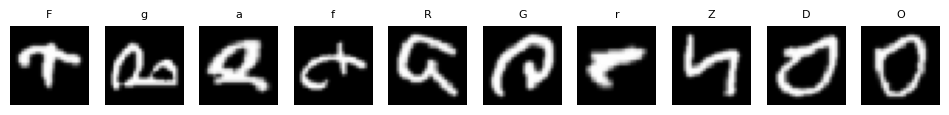

In [20]:

def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [16]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")
        
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)
        

model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)
    

logits: torch.Size([64, 10])


In [26]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc  = 0.0
    n_batches = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc  = 0.0
    n_batches = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


In [27]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [28]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=1.1347, acc=0.6650 | val loss=0.7416, acc=0.7712
epoch 02/20 | train loss=0.6572, acc=0.7875 | val loss=0.6233, acc=0.8001
epoch 03/20 | train loss=0.5602, acc=0.8125 | val loss=0.5499, acc=0.8245
epoch 04/20 | train loss=0.5067, acc=0.8273 | val loss=0.5701, acc=0.8144
epoch 05/20 | train loss=0.4733, acc=0.8372 | val loss=0.5321, acc=0.8287
epoch 06/20 | train loss=0.4438, acc=0.8454 | val loss=0.5167, acc=0.8327
epoch 07/20 | train loss=0.4234, acc=0.8490 | val loss=0.5208, acc=0.8279
epoch 08/20 | train loss=0.4067, acc=0.8542 | val loss=0.5343, acc=0.8294
epoch 09/20 | train loss=0.3929, acc=0.8577 | val loss=0.5106, acc=0.8370
epoch 10/20 | train loss=0.3753, acc=0.8632 | val loss=0.5350, acc=0.8303
epoch 11/20 | train loss=0.3662, acc=0.8656 | val loss=0.5272, acc=0.8315
epoch 12/20 | train loss=0.3538, acc=0.8698 | val loss=0.5235, acc=0.8370
epoch 13/20 | train loss=0.3458, acc=0.8716 | val loss=0.5241, acc=0.8381
epoch 14/20 | train loss=0.3396, acc=0

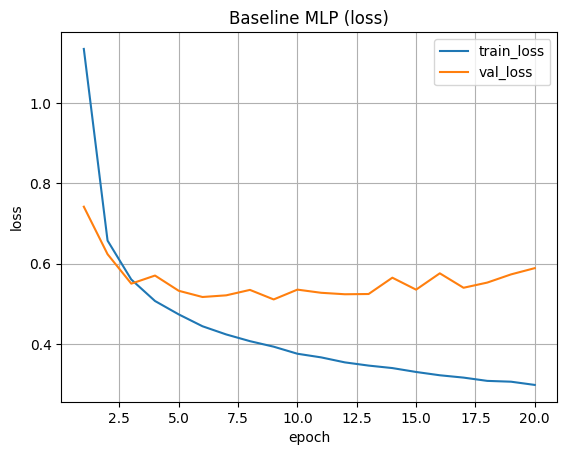

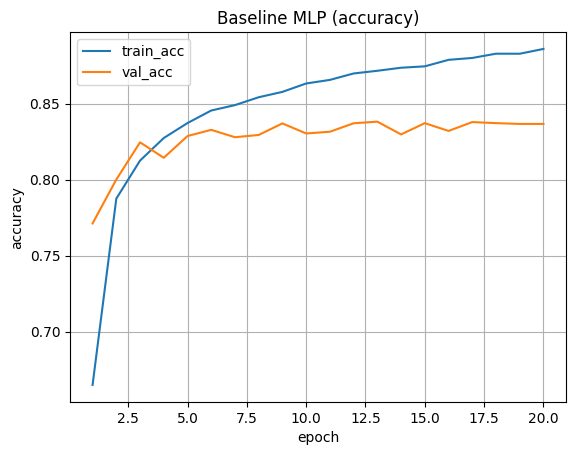

In [ ]:
set_seed(SEED)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False, num_classes=47).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [36]:
new_record = pd.DataFrame([{
        'experiment_id': "E1",
        'dataset': "EMNIST",
        'seed': SEED,
        'model_summary': "hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False,",
        'optimizer': "Adam",
        'lr': 1e-3,
        'momentum':  0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.8381,
        'best_val_loss': 0.5241
    }])

runs_df = pd.concat([runs_df, new_record], ignore_index=True)

C:\Users\Lenovo-PC\AppData\Local\Temp\ipykernel_1784\2796550864.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs_df = pd.concat([runs_df, new_record], ignore_index=True)


epoch 01/20 | train loss=1.5223, acc=0.5536 | val loss=0.8382, acc=0.7379
epoch 02/20 | train loss=1.0375, acc=0.6805 | val loss=0.7099, acc=0.7784
epoch 03/20 | train loss=0.9401, acc=0.7045 | val loss=0.6541, acc=0.7894
epoch 04/20 | train loss=0.8885, acc=0.7172 | val loss=0.6363, acc=0.7964
epoch 05/20 | train loss=0.8560, acc=0.7261 | val loss=0.6041, acc=0.8057
epoch 06/20 | train loss=0.8395, acc=0.7319 | val loss=0.5938, acc=0.8068
epoch 07/20 | train loss=0.8224, acc=0.7365 | val loss=0.5825, acc=0.8116
epoch 08/20 | train loss=0.8063, acc=0.7409 | val loss=0.5625, acc=0.8184
epoch 09/20 | train loss=0.7993, acc=0.7429 | val loss=0.5798, acc=0.8075
epoch 10/20 | train loss=0.7882, acc=0.7457 | val loss=0.5541, acc=0.8181
epoch 11/20 | train loss=0.7829, acc=0.7454 | val loss=0.5555, acc=0.8196
epoch 12/20 | train loss=0.7695, acc=0.7504 | val loss=0.5479, acc=0.8190
epoch 13/20 | train loss=0.7635, acc=0.7520 | val loss=0.5483, acc=0.8211
epoch 14/20 | train loss=0.7594, acc=0

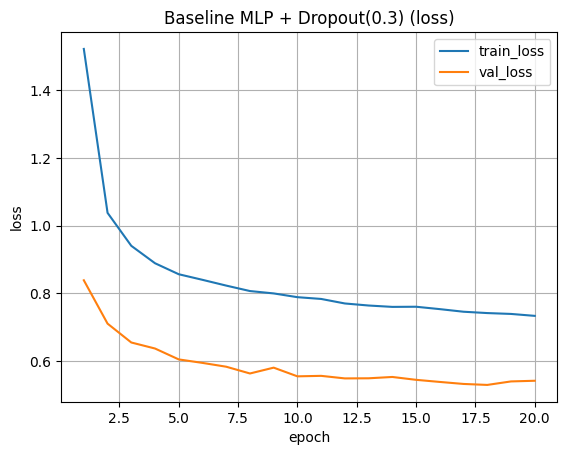

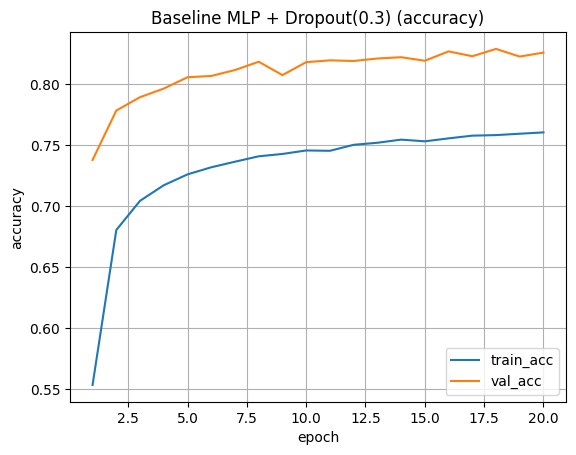

In [30]:
set_seed(SEED)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False, num_classes=47).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP + Dropout(0.3)")

In [37]:
new_record = pd.DataFrame([{
        'experiment_id': "E2",
        'dataset': "EMNIST",
        'seed': SEED,
        'model_summary': "hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False,",
        'optimizer': "Adam",
        'lr': 1e-3,
        'momentum':  0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.8289,
        'best_val_loss': 0.5287
    }])

runs_df = pd.concat([runs_df, new_record], ignore_index=True)

epoch 01/20 | train loss=0.8866, acc=0.7436 | val loss=0.5699, acc=0.8154
epoch 02/20 | train loss=0.5277, acc=0.8230 | val loss=0.5148, acc=0.8289
epoch 03/20 | train loss=0.4583, acc=0.8425 | val loss=0.4695, acc=0.8420
epoch 04/20 | train loss=0.4177, acc=0.8526 | val loss=0.4684, acc=0.8436
epoch 05/20 | train loss=0.3852, acc=0.8622 | val loss=0.4499, acc=0.8495
epoch 06/20 | train loss=0.3651, acc=0.8693 | val loss=0.4533, acc=0.8491
epoch 07/20 | train loss=0.3448, acc=0.8732 | val loss=0.4476, acc=0.8493
epoch 08/20 | train loss=0.3276, acc=0.8766 | val loss=0.4498, acc=0.8528
epoch 09/20 | train loss=0.3131, acc=0.8819 | val loss=0.4400, acc=0.8543
epoch 10/20 | train loss=0.3010, acc=0.8863 | val loss=0.4433, acc=0.8519
epoch 11/20 | train loss=0.2873, acc=0.8891 | val loss=0.4510, acc=0.8535
epoch 12/20 | train loss=0.2773, acc=0.8930 | val loss=0.4454, acc=0.8563
epoch 13/20 | train loss=0.2691, acc=0.8957 | val loss=0.4697, acc=0.8513
epoch 14/20 | train loss=0.2603, acc=0

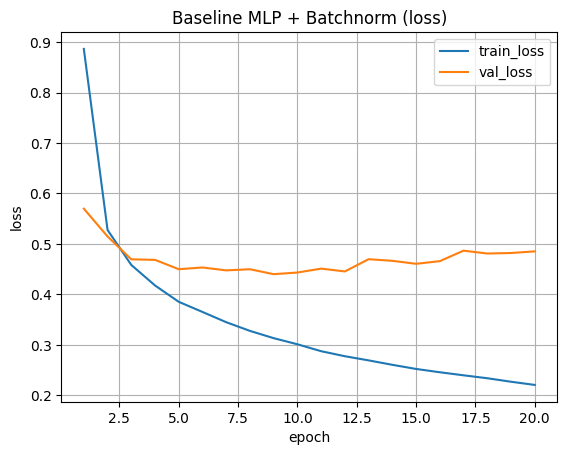

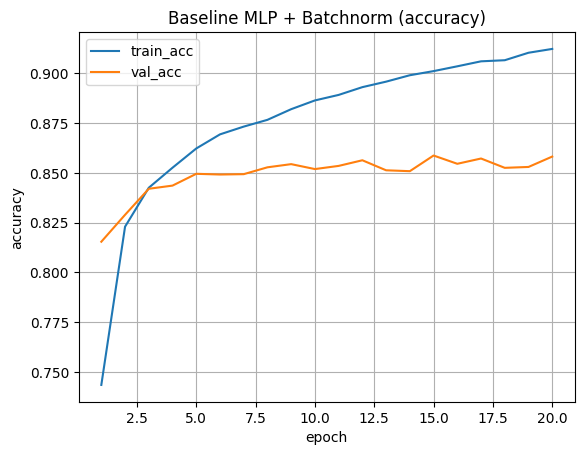

In [34]:
set_seed(SEED)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True, num_classes=47).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP + Batchnorm")

In [38]:
new_record = pd.DataFrame([{
        'experiment_id': "E3",
        'dataset': "EMNIST",
        'seed': SEED,
        'model_summary': "hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True,",
        'optimizer': "Adam",
        'lr': 1e-3,
        'momentum':  0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.8587,
        'best_val_loss': 0.4606
    }])

runs_df = pd.concat([runs_df, new_record], ignore_index=True)

In [39]:
runs_df.head()

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"hidden_dims=(256, 128), dropout_p=0.0, use_bat...",Adam,0.001,0,0,20,0.8381,0.5241
1,E2,EMNIST,42,"hidden_dims=(256, 128), dropout_p=0.3, use_bat...",Adam,0.001,0,0,20,0.8289,0.5287
2,E3,EMNIST,42,"hidden_dims=(256, 128), dropout_p=0.0, use_bat...",Adam,0.001,0,0,20,0.8587,0.4606


epoch 01/40 | train loss=0.8866, acc=0.7436 | val loss=0.5699, acc=0.8154
epoch 02/40 | train loss=0.5277, acc=0.8230 | val loss=0.5148, acc=0.8289
epoch 03/40 | train loss=0.4583, acc=0.8425 | val loss=0.4695, acc=0.8420
epoch 04/40 | train loss=0.4177, acc=0.8526 | val loss=0.4684, acc=0.8436
epoch 05/40 | train loss=0.3852, acc=0.8622 | val loss=0.4499, acc=0.8495
epoch 06/40 | train loss=0.3651, acc=0.8693 | val loss=0.4533, acc=0.8491
epoch 07/40 | train loss=0.3448, acc=0.8732 | val loss=0.4476, acc=0.8493
epoch 08/40 | train loss=0.3276, acc=0.8766 | val loss=0.4498, acc=0.8528
epoch 09/40 | train loss=0.3131, acc=0.8819 | val loss=0.4400, acc=0.8543
epoch 10/40 | train loss=0.3010, acc=0.8863 | val loss=0.4433, acc=0.8519
epoch 11/40 | train loss=0.2873, acc=0.8891 | val loss=0.4510, acc=0.8535
epoch 12/40 | train loss=0.2773, acc=0.8930 | val loss=0.4454, acc=0.8563
epoch 13/40 | train loss=0.2691, acc=0.8957 | val loss=0.4697, acc=0.8513
epoch 14/40 | train loss=0.2603, acc=0

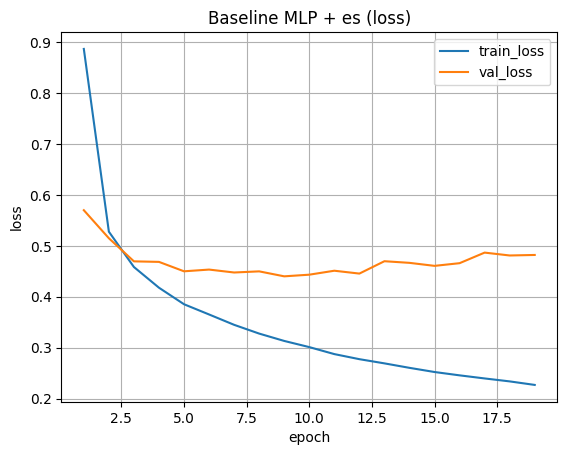

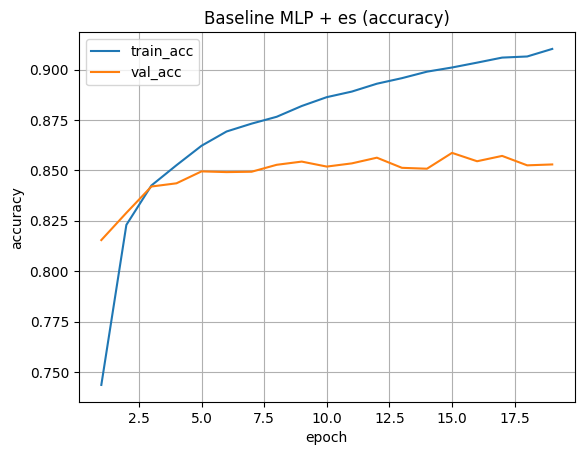

In [65]:
set_seed(SEED)
baseline_es = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True, num_classes=47).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_es.parameters(), lr=1e-3)
es = EarlyStopping(patience=4, min_delta=0.0005)
history_baseline = fit(
    baseline_es, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=40,
    early_stopping=es
)

plot_history(history_baseline, title="Baseline MLP + es")

In [ ]:
new_record = pd.DataFrame([{
        'experiment_id': "E4",
        'dataset': "EMNIST",
        'seed': SEED,
        'model_summary': "hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True, ErlyStoping=True",
        'optimizer': "Adam",
        'lr': 1e-3,
        'momentum':  0,
        'weight_decay': 0,
        'epochs_trained': 19,
        'best_val_accuracy': 0.8587,
        'best_val_loss': 0.4606
    }])

runs_df = pd.concat([runs_df, new_record], ignore_index=True)


In [69]:
result = evaluate(baseline_es, test_loader, nn.CrossEntropyLoss(), device)[1]
acc = result
print(f"Test accuracy: {acc:.4f}")

Test accuracy: 0.8534


In [71]:
torch.save(baseline_es.state_dict(), './artifacts/best_model.pt')

In [44]:
import json

best_config = {
    "model_architecture": {
        "type": "MLP",
        "input_size": 784,  # для MNIST/KMNIST 28x28
        "hidden_sizes": [512, 256, 128],
        "activation": "ReLU",
        "dropout": 0.0,
        "batch_norm": True
    },
    "training_params": {
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "weight_decay": 0,
        "batch_size": 64,
        "loss_function": "CrossEntropyLoss",
        "epochs": 19
    },
    "dataset": {
        "name": "EMNIST",
        "num_classes": 10,
        "input_shape": [1, 28, 28],
        "train_samples": 60000,
        "val_samples": 10000
    },
    "best_metrics": {
        "epoch": 15,
        "val_accuracy": 0.8587,
        "val_loss": 0.4606,
    },
    "seed": 42,
    "experiment_id": "E4",
    
}

# Сохраняем в файл
with open('./artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

## 09

epoch 01/8 | train loss=1.1905, acc=0.6454 | val loss=0.8475, acc=0.7378
epoch 02/8 | train loss=0.8910, acc=0.7227 | val loss=0.8320, acc=0.7406
epoch 03/8 | train loss=0.8054, acc=0.7464 | val loss=0.7497, acc=0.7591
epoch 04/8 | train loss=0.7726, acc=0.7551 | val loss=0.6946, acc=0.7745
epoch 05/8 | train loss=0.7219, acc=0.7694 | val loss=0.6670, acc=0.7952
epoch 06/8 | train loss=0.7072, acc=0.7721 | val loss=0.6481, acc=0.8001
epoch 07/8 | train loss=0.6916, acc=0.7759 | val loss=0.6900, acc=0.7914
epoch 08/8 | train loss=0.6748, acc=0.7809 | val loss=0.7190, acc=0.7705


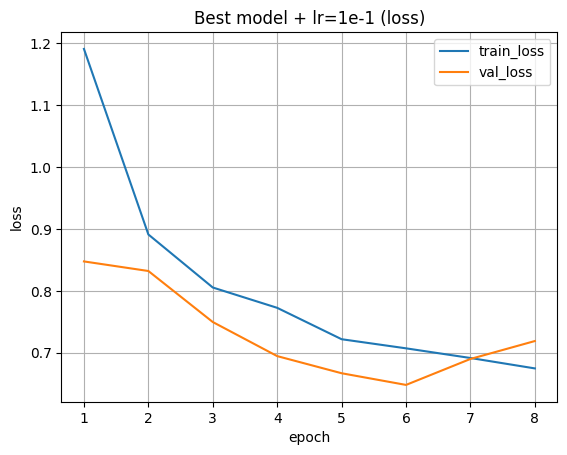

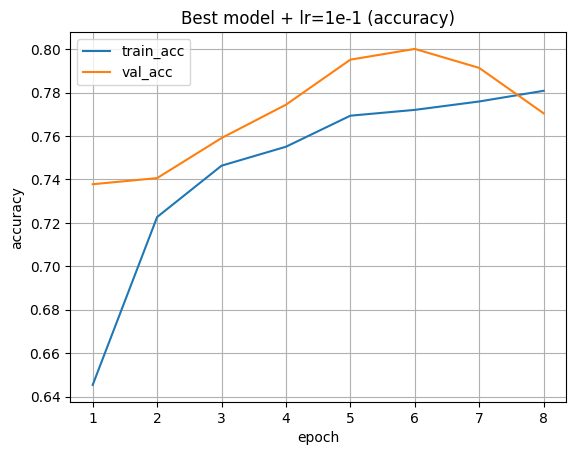

In [52]:
set_seed(SEED)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True, num_classes=47).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-1)
es = EarlyStopping(patience=4, min_delta=0.0005)
history_o1 = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es
)

plot_history(history_o1, title="Best model + lr=1e-1")

In [46]:
new_record = pd.DataFrame([{
        'experiment_id': "O1",
        'dataset': "EMNIST",
        'seed': SEED,
        'model_summary': "hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True, ErlyStoping=True",
        'optimizer': "Adam",
        'lr': 1e-1,
        'momentum':  0,
        'weight_decay': 0,
        'epochs_trained': 8,
        'best_val_accuracy': 0.8001,
        'best_val_loss': 0.6481
    }])

runs_df = pd.concat([runs_df, new_record], ignore_index=True)


epoch 01/8 | train loss=3.2802, acc=0.2490 | val loss=2.8342, acc=0.4367
epoch 02/8 | train loss=2.6034, acc=0.4979 | val loss=2.3591, acc=0.5577
epoch 03/8 | train loss=2.2144, acc=0.5810 | val loss=2.0259, acc=0.6185
epoch 04/8 | train loss=1.9200, acc=0.6275 | val loss=1.7734, acc=0.6528
epoch 05/8 | train loss=1.6870, acc=0.6589 | val loss=1.5650, acc=0.6757
epoch 06/8 | train loss=1.5042, acc=0.6799 | val loss=1.3982, acc=0.6977
epoch 07/8 | train loss=1.3572, acc=0.7001 | val loss=1.2778, acc=0.7118
epoch 08/8 | train loss=1.2376, acc=0.7150 | val loss=1.1645, acc=0.7253


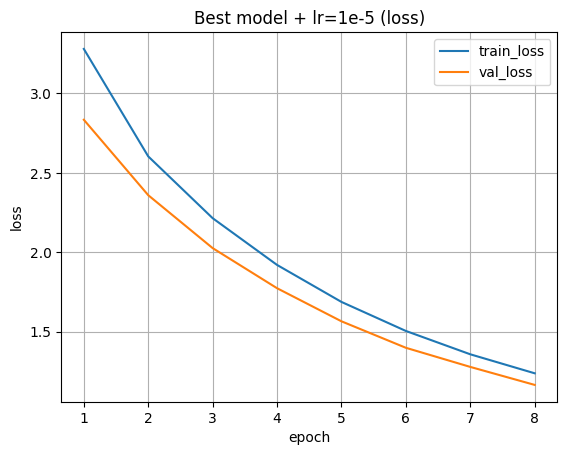

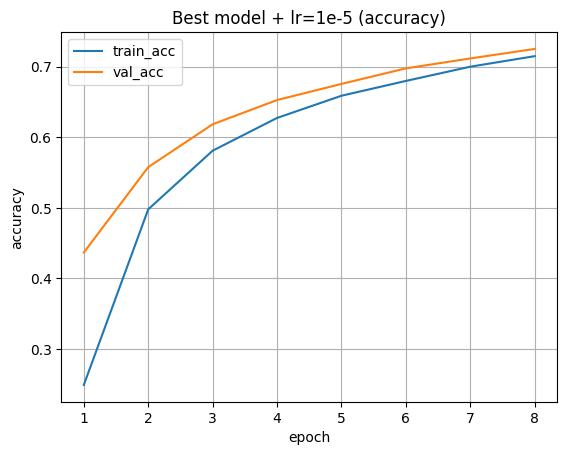

In [53]:
set_seed(SEED)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True, num_classes=47).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-5)
es = EarlyStopping(patience=4, min_delta=0.0005)
history_o2 = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es
)

plot_history(history_o2, title="Best model + lr=1e-5")

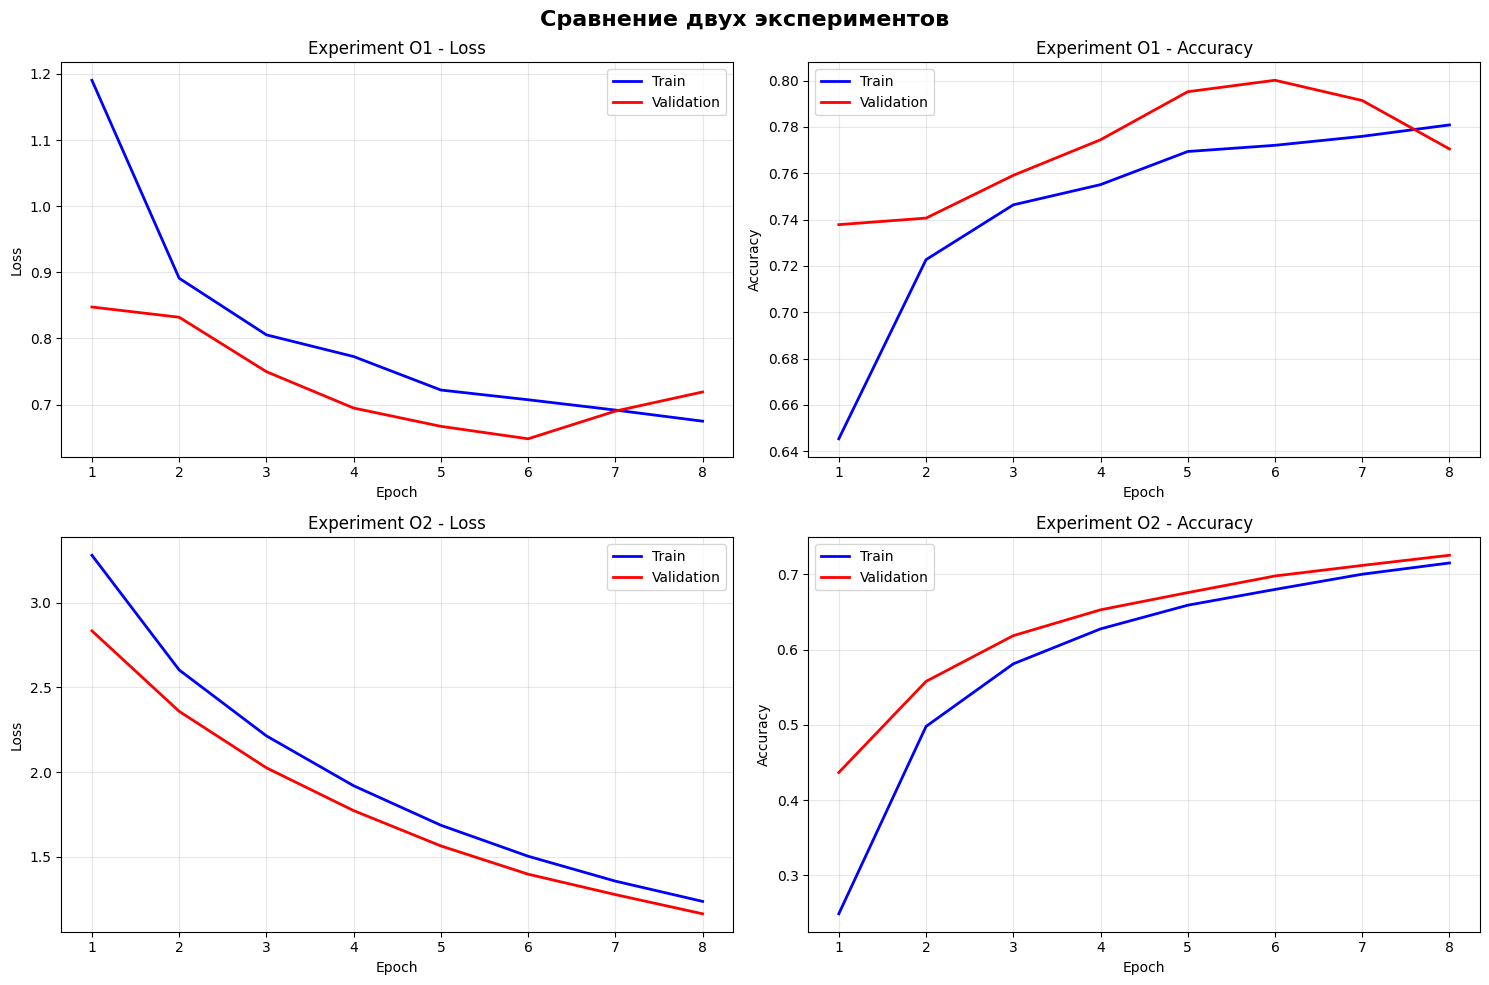

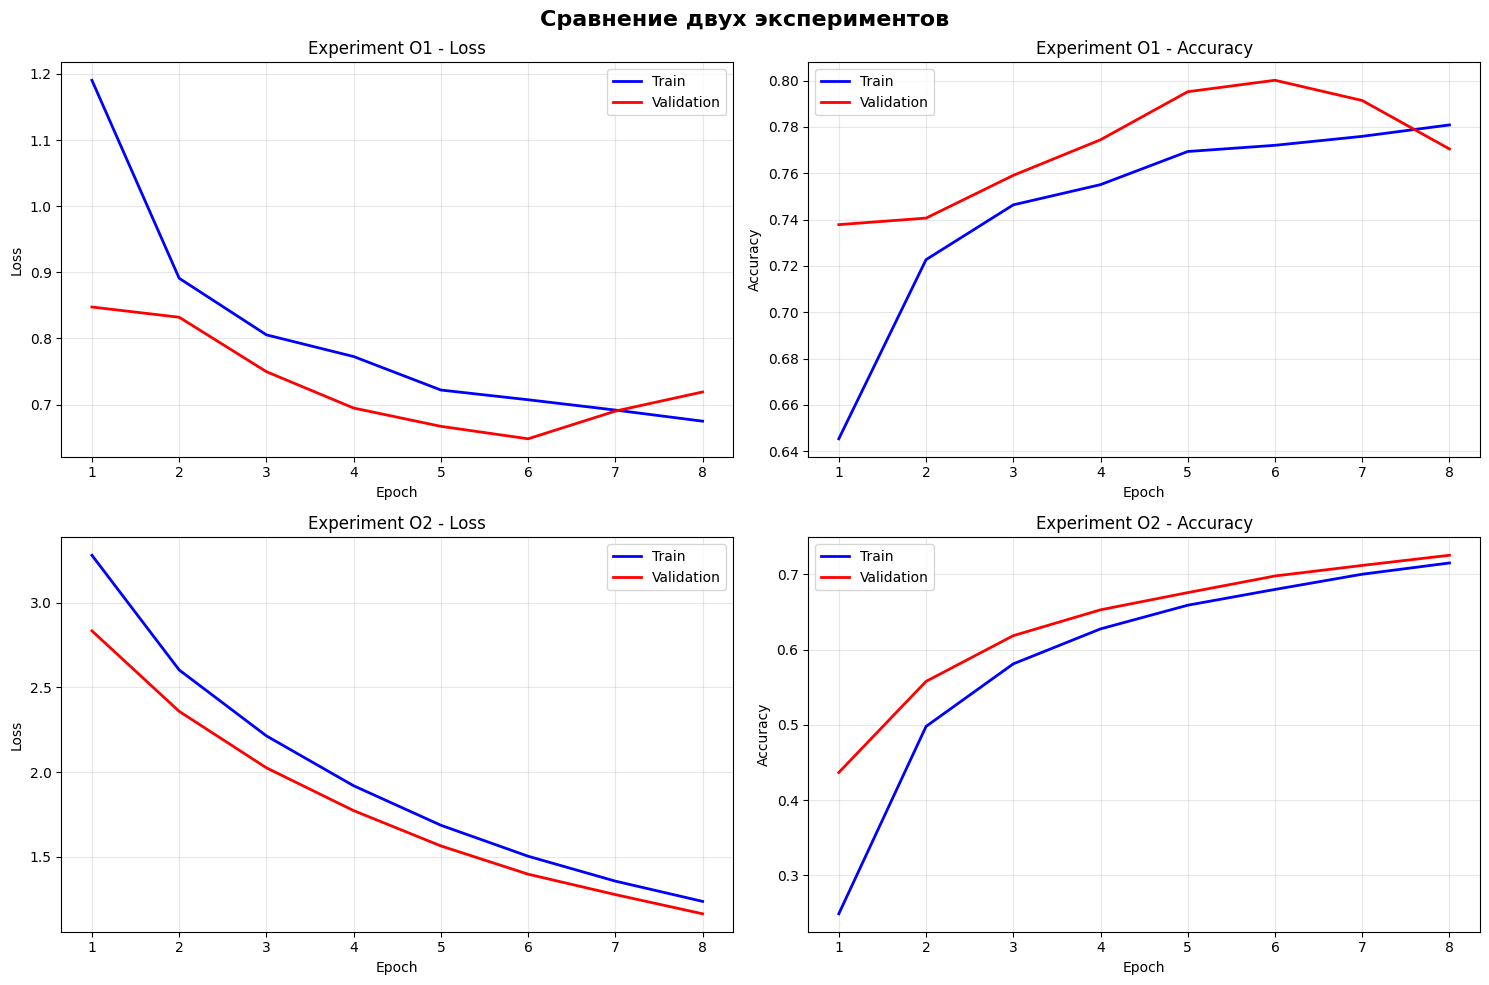

In [54]:
import matplotlib.pyplot as plt

def plot_two_experiments(history1, history2, 
                         title1="Experiment O1", 
                         title2="Experiment O2",
                         save_path="./artifacts/figures/curves_lr_extremes.png"):
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs1 = range(1, len(history1['train_loss']) + 1)
    epochs2 = range(1, len(history2['train_loss']) + 1)
    
    # Эксперимент 1 - Loss
    axes[0, 0].plot(epochs1, history1['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0, 0].plot(epochs1, history1['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title(f'{title1} - Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Эксперимент 1 - Accuracy
    axes[0, 1].plot(epochs1, history1['train_acc'], 'b-', label='Train', linewidth=2)
    axes[0, 1].plot(epochs1, history1['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title(f'{title1} - Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Эксперимент 2 - Loss
    axes[1, 0].plot(epochs2, history2['train_loss'], 'b-', label='Train', linewidth=2)
    axes[1, 0].plot(epochs2, history2['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].set_title(f'{title2} - Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Эксперимент 2 - Accuracy
    axes[1, 1].plot(epochs2, history2['train_acc'], 'b-', label='Train', linewidth=2)
    axes[1, 1].plot(epochs2, history2['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].set_title(f'{title2} - Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Сравнение двух экспериментов', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()
    return fig

# Использование:
plot_two_experiments(history_o1, history_o2)

In [48]:
new_record = pd.DataFrame([{
        'experiment_id': "O2",
        'dataset': "EMNIST",
        'seed': SEED,
        'model_summary': "hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True, ErlyStoping=True",
        'optimizer': "Adam",
        'lr': 1e-5,
        'momentum':  0,
        'weight_decay': 0,
        'epochs_trained': 8,
        'best_val_accuracy': 0.7253,
        'best_val_loss': 1.1645
    }])

runs_df = pd.concat([runs_df, new_record], ignore_index=True)


epoch 01/8 | train loss=1.8493, acc=0.5834 | val loss=1.0638, acc=0.7269
epoch 02/8 | train loss=0.9071, acc=0.7524 | val loss=0.7452, acc=0.7912
epoch 03/8 | train loss=0.6979, acc=0.7943 | val loss=0.6277, acc=0.8122
epoch 04/8 | train loss=0.6026, acc=0.8157 | val loss=0.5749, acc=0.8228
epoch 05/8 | train loss=0.5444, acc=0.8288 | val loss=0.5447, acc=0.8283
epoch 06/8 | train loss=0.5076, acc=0.8374 | val loss=0.5186, acc=0.8339
epoch 07/8 | train loss=0.4769, acc=0.8445 | val loss=0.5032, acc=0.8377
epoch 08/8 | train loss=0.4522, acc=0.8509 | val loss=0.4938, acc=0.8381


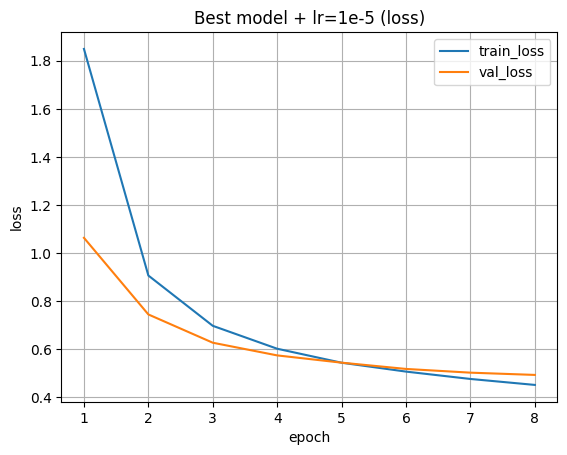

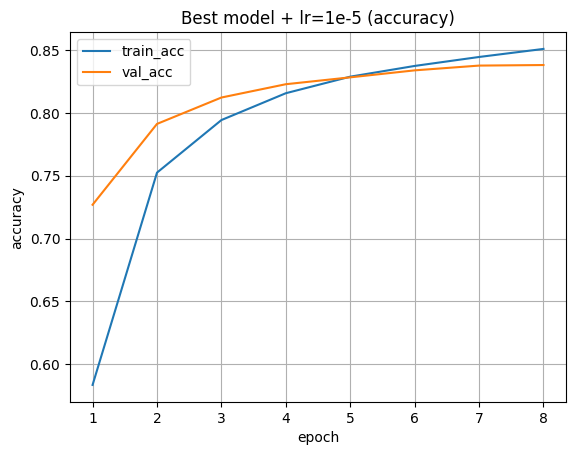

In [49]:
set_seed(SEED)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True, num_classes=47).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(baseline.parameters(), lr=1e-3, momentum=0.9, weight_decay= 1e-4)
es = EarlyStopping(patience=4, min_delta=0.0005)
history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es
)

plot_history(history_baseline, title="Best model + lr=1e-5")

In [55]:
new_record = pd.DataFrame([{
        'experiment_id': "O3",
        'dataset': "EMNIST",
        'seed': SEED,
        'model_summary': "hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True, ErlyStoping=True",
        'optimizer': "SGD",
        'lr': 1e-3,
        'momentum':  0.9,
        'weight_decay': 1e-4,
        'epochs_trained': 8,
        'best_val_accuracy': 0.8381,
        'best_val_loss': 0.4938
    }])

runs_df = pd.concat([runs_df, new_record], ignore_index=True)

In [56]:
runs_df.to_csv('./artifacts/runs.csv', index=False)